In [1]:
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
  Using cached protobuf-7.35.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/351.2 MB 2.2 MB/s eta 0:02:42
   ---------------------------------------- 1.0/351.2 MB 1.8 MB/s eta 0:03:20
   ---------------------------------------- 1.3/351.2 MB 1.7 MB/s eta 0:03:24
   ---------------------------------------- 1.8/351.2 MB 1.8 MB/s eta 0:03:16
   ---------------------------------------- 2.4/351.2 MB 1.8 MB/s eta 0:03:09
   ---------------------------------------- 2.9/351.2 MB 1.9 MB/s eta 0:03:03
   ---------------------------------------- 3.1/351.2 MB 1.9 MB/s eta 0:03:03
   ---------------------------------------- 3.7/351.2 MB 2.0 MB/s eta 0:02:57
   ---------------------------------------- 4.2/351.2 MB 2.0 MB/s eta 0:02:52
 

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.35.1 which is incompatible.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

In [3]:
print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.21.0


In [4]:
df = pd.read_csv('data.csv')
df.head()

,x,y
0,74.128461,357.046360
1,39.705725,206.225240
2,1.327203,2.163316
3,86.752451,412.080923
4,32.803825,171.032648


In [5]:
print("Shape of the dataset:", df.shape)

Shape of the dataset: (230, 2)


In [8]:
print("Column names:", df.columns.tolist())

Column names: ['x', 'y']


In [9]:
df.dtypes

x    float64
y    float64
dtype: object

In [10]:
df.head(10)

,x,y
0,74.128461,357.046360
1,39.705725,206.225240
2,1.327203,2.163316
3,86.752451,412.080923
4,32.803825,171.032648
5,82.203090,353.567737
6,43.325559,186.700912
7,15.793323,105.126081
8,50.544917,249.887001
9,45.902279,220.461495


In [11]:
df.tail(10)

,x,y
220,93.520051,509.240839
221,80.704001,190.956506
222,60.278873,199.887734
223,10.792489,-121.928951
224,88.555871,583.305692
225,46.424221,435.156719
226,21.129404,238.283335
227,27.307588,288.126693
228,57.563927,98.672413
229,98.118260,275.677750


In [12]:
df.describe()

,x,y
count,230.000000,230.000000
mean,51.570888,232.106834
std,29.750511,139.691624
min,0.626288,-121.928951
25%,26.916945,119.219180
50%,51.250974,237.056374
75%,77.840782,343.532195
max,99.816856,583.305692


In [13]:
print("Missing Values per column:")
print(df.isna().sum())

Missing Values per column:
x    0
y    0
dtype: int64


In [14]:
num_duplicates = df.duplicated().sum()
print(f"Number of duplicatd rows: {num_duplicates}")

Number of duplicatd rows: 0


In [16]:
print("x range:", df['x'].min(), "to", df['x'].max())
print("y range:", df['y'].min(), "to", df['y'].max())

x range: 0.6262881976694112 to 99.81685649702948
y range: -121.92895093094808 to 583.3056923127526


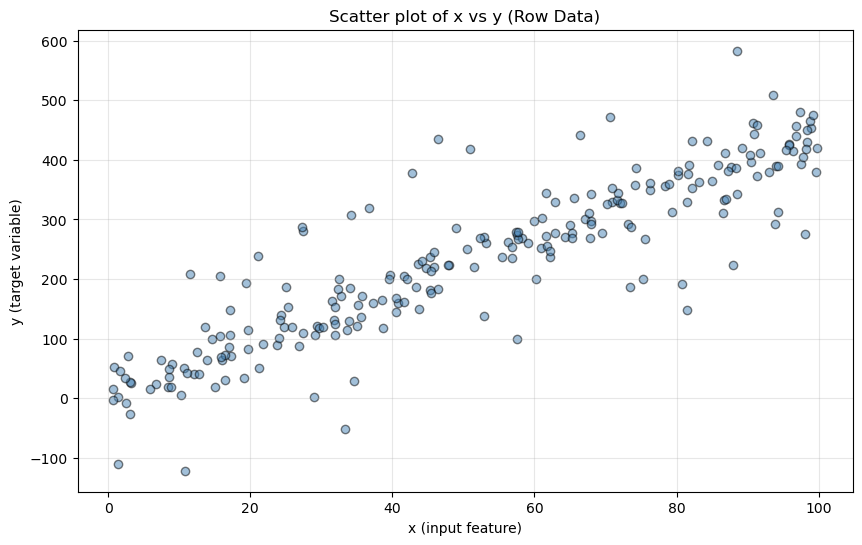

In [17]:
plt.figure(figsize=(10, 6))
plt.scatter(df['x'], df['y'], alpha=0.5, color='steelblue', edgecolors='k')
plt.title('Scatter plot of x vs y (Row Data)')
plt.xlabel('x (input feature)')
plt.ylabel('y (target variable)')
plt.grid(alpha=0.3)
plt.show()

In [18]:
correlation = df['x'].corr(df['y'])
print(f"Correlation between x and y: {correlation:.4f}")

Correlation between x and y: 0.8937


In [19]:
if correlation > 0.7:
    strength = 'a strong positive'
elif correlation > 0.3:
    strength = 'a moderate positive'
elif correlation > 0:
    strength = 'a week positive'
elif correlation > -0.3:
    strength = 'a week negative'
elif correlation > -0.7:
    strength = 'a moderate negative'
else:
    strength = 'a strong negative'

print(f"The correlation between x and y is {strength}")

The correlation between x and y is a strong positive


In [20]:
# pred(y) = wx + b
# where x = inut feature, y = target variable, w = weight(slope), b = bias (intercept)

In [21]:
X_all = df[['x']]
y_all = df['y']

baseline_lr = LinearRegression()
baseline_lr.fit(X_all, y_all)

baseline_weight = baseline_lr.coef_[0]
baseline_bias = baseline_lr.intercept_

print(f'Baseline linear regression weight (slope): {baseline_weight:.4f}')
print(f'Baseline linear regression bias (intercept): {baseline_bias:.4f}')
print(f'Baseline linear regression equation: y = {baseline_weight:.4f}* x + (baseline_bias:.4f)')
print(f'Baseline R^2 score: {baseline_lr.score(X_all, y_all):4f}')

Baseline linear regression weight (slope): 4.1965
Baseline linear regression bias (intercept): 15.6875
Baseline linear regression equation: y = 4.1965* x + (baseline_bias:.4f)
Baseline R^2 score: 0.798787


In [24]:
sample_row = df.iloc[0]
x_sample = sample_row['x']
y_actual = sample_row['y']

print(f"We picked row 0 from the dataset:")
print(f"   x (input) = {x_sample:.4f}")
print(f"   y (actual / true) = {y_actual:.4f}")

We picked row 0 from the dataset:
   x (input) = 74.1285
   y (actual / true) = 357.0464


In [25]:
w_demo = 2.0
b_demo = 0.0

y_hat_demo = w_demo * x_sample + b_demo
error_demo = y_actual - y_hat_demo

print(f"Choose weight w = {w_demo} and bias b = {b_demo}")
print(f"Prediction: y_hat = w * x + b = {w_demo} * {x_sample:.4f} + {b_demo} = {y_hat_demo:.4f}")
print(f"Actual y = {y_actual:.4f}")
print(f"Error (actual - Predicted) = {error_demo:.4f}")

Choose weight w = 2.0 and bias b = 0.0
Prediction: y_hat = w * x + b = 2.0 * 74.1285 + 0.0 = 148.2569
Actual y = 357.0464
Error (actual - Predicted) = 208.7894
